# **Import Libraries**

In [157]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Load Dataset**

In [158]:
import pandas as pd

# 1. Parquet load karein
df = pd.read_parquet('credit_card_frauds.parquet')

# 2. Parquet mein convert karke save karein
# Isse file size kafi kam ho jayega
df.to_parquet('credit_card_frauds.parquet', index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [159]:
df.shape

(339607, 15)

> The dataset contains 339,607 rows and 15 columns, and uses three types of data: float, int, and string.

In [160]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


##### **In this dataframe,The columns define as:** 
`trans_date_trans_time:` the date and time when the transaction occurred  
`merchant:` the store or merchant where the purchase was made  
`category:` the type of purchase  
`amt:` the transaction amount  
`city & state:` the location of the customer  
`lat & long:` the latitude and longitude of the customer's location  
`city_pop:` the population of the city  
`job:` the customer's occupation  
`dob:` the customer's date of birth  
`trans_num:` a unique transaction ID  
`merch_lat & merch_long:` the latitude and longitude of the merchant's location  
`is fraud:` indicates whether the transaction is fraudulent (0= False, 1 = True)  
The columns `trans_date_trans_time` and `dob` are in `string` format, so they should be converted into `datetime` format for better analysis.

In [161]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


In [162]:
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [163]:
df.isnull().sum().sum()

0

> The given dataset contains 0 null values which means the data is clean in null value perspectives.

In [164]:
df['is_fraud'].mean()

0.005247241664629999

In [165]:
df['is_fraud'].mean() * 100

0.5247241664629999

In [166]:
df['is_fraud'].value_counts()

0    337825
1      1782
Name: is_fraud, dtype: int64

Most transactions are normal and fraud transactions are very few, which indicates that the dataset is highly imbalanced

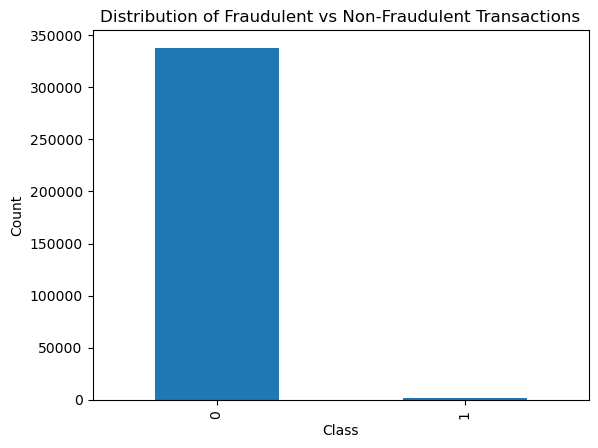

In [167]:
df['is_fraud'].value_counts().plot(kind='bar')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Class')
plt.ylabel('Count') 
plt.show()

The number of non-fraudulent transactions is significantly higher than fraudulent ones. Fraud cases represent only a very small portion of the dataset, indicating a highly imbalanced dataset. This imbalance can affect model performance, as machine learning algorithms may become biased toward predicting non-fraud transactions.

# **Handling Imbalanced Data**

In [168]:
fraud = df[df['is_fraud'] == 1]
non_fraud = df[df['is_fraud'] == 0]

fraud_sample = fraud

non_fraud_sample = non_fraud.sample(n=2218, random_state=42)

df = pd.concat([fraud_sample, non_fraud_sample])

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df['is_fraud'].value_counts())

0    2218
1    1782
Name: is_fraud, dtype: int64


In [169]:
len(df)

4000

The dataset was highly imbalanced, with a large number of non-fraud (0) transactions and very few fraud (1) transactions. To balance the data, we kept all the fraud transactions and randomly selected a subset of non-fraud transactions. We performed undersampling to handle class imbalance in the dataset. Undersampling is a sampling technique in which we reduce the majority class (non-fraud) to balance the dataset for better model training and prediction.

In [170]:
df.duplicated().sum()

0

In [171]:
df['is_fraud'].value_counts()

0    2218
1    1782
Name: is_fraud, dtype: int64

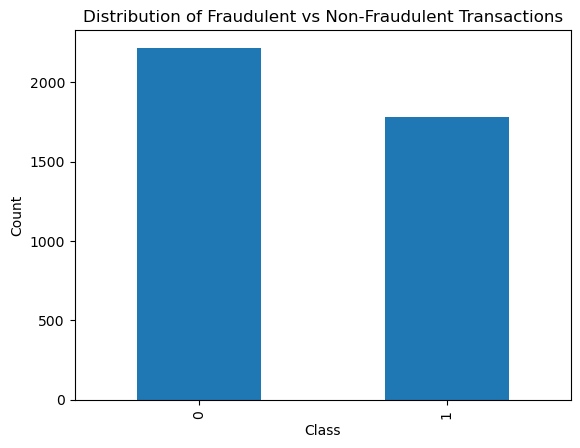

In [172]:
df['is_fraud'].value_counts().plot(kind='bar')
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Class')
plt.ylabel('Count') 
plt.show()

The updated class distribution shows that there are 2218 non-fraud (0) transactions and 1782 fraud (1) transactions. Although not perfectly equal, the dataset is now reasonably balanced compared to the original distribution. This balanced data helps machine learning models perform better because the model can learn from both fraud and non-fraud cases more fairly.


In [173]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

# **Feature Engineering**

In [174]:
df['trans_date_trans_time'].unique()

array(['2019-08-05 00:22:03', '2020-08-27 11:53:54',
       '2019-07-26 01:05:31', ..., '2019-11-30 01:24:29',
       '2020-11-16 12:58:20', '2020-01-07 15:31:06'], dtype=object)

**Datetime Cnversion**

In [175]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_date_trans_time'].dtype

dtype('<M8[ns]')

In [176]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

# **Feature Selection**

In [177]:
df.drop(columns = ['job' , 'merchant' , 'trans_num'], inplace=True)

>  Dropping unnecessary columns:\
 **trans_num:**\
 Unique transaction ID, does not help in prediction.\
 **merchant:**\
 High-cardinality column with too many unique values.\
 It may increase model complexity.\
 **job:**\
 Not strongly related to fraud prediction.


In [178]:
df.columns

Index(['trans_date_trans_time', 'category', 'amt', 'city', 'state', 'lat',
       'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

We removed unnecessary columns from the dataframe to make the data simpler and more clear. This helps us keep only the useful features, which can improve the performance of the machine learning model.

In [179]:
df.shape

(4000, 12)

In [180]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,4000.000000,4000.000000,4000.00000,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,267.068427,39.964609,-111.05230,1.144123e+05,39.949394,-111.064038,0.445500
std,351.106572,5.576083,13.37647,3.069934e+05,5.617396,13.402309,0.497083
min,1.050000,20.027100,-165.67230,4.600000e+01,19.078440,-166.651656,0.000000
25%,18.342500,36.715400,-120.66490,5.090000e+02,36.794016,-120.496442,0.000000
50%,76.305000,39.753200,-111.79410,1.645000e+03,39.722256,-111.417743,0.000000
75%,335.225000,42.277000,-99.38440,3.550550e+04,42.339203,-99.696236,1.000000
max,1371.810000,66.693300,-89.62870,2.383912e+06,67.510267,-88.646366,1.000000


# **Insights**

### **1. What does the transaction amount distribution indicate?**

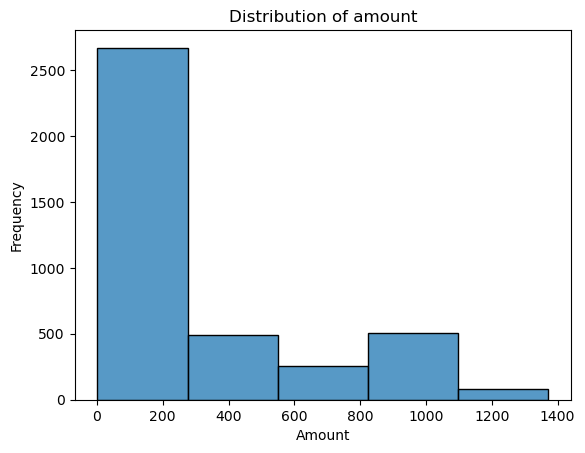

In [181]:
sns.histplot(df, x='amt', bins=5)
plt.title('Distribution of amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

This histogram shows the distribution of transaction amounts. The x-axis represents the transaction amount, while the y-axis represents the frequency of transactions. The graph indicates that most transactions occur in the lower amount range (0-200), whereas very few transactions occur at higher amounts. This means low-value transactions are more common compared to high-value transactions, while high-value transactions are relatively rare and may require closer monitoring as they could be unusual or suspicious.

### **2. What does the box plot reveal about transaction amounts?**

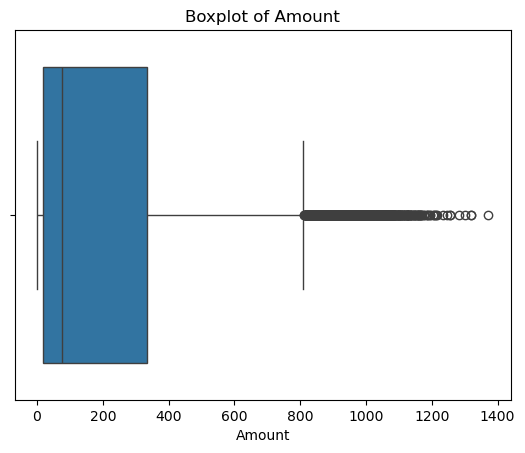

In [182]:
sns.boxplot(x=(df['amt']))
plt.title('Boxplot of Amount')
plt.xlabel('Amount')
plt.show()

This box plot shows the distribution of transaction amounts. It indicates that most transactions are in the lower range, and the median is also on the lower side. Some values are far from the normal range, which represent outliers, meaning there are also a few high-value transactions in the dataset. These unusual high-value transactions may be important to investigate further, as they could indicate abnormal or potentially fraudulent activity.

### **3. What does the category-wise fraud analysis indicate?**

In [183]:
df.category.unique()

array(['misc_pos', 'gas_transport', 'grocery_pos', 'kids_pets',
       'food_dining', 'misc_net', 'home', 'shopping_net', 'personal_care',
       'shopping_pos', 'entertainment', 'grocery_net', 'travel',
       'health_fitness'], dtype=object)

In [184]:
df.category.nunique()

14

In [185]:
df.category.value_counts()

grocery_pos       618
shopping_net      573
shopping_pos      380
gas_transport     367
misc_net          342
kids_pets         265
home              259
personal_care     229
entertainment     222
food_dining       186
health_fitness    174
misc_pos          165
grocery_net       116
travel            104
Name: category, dtype: int64

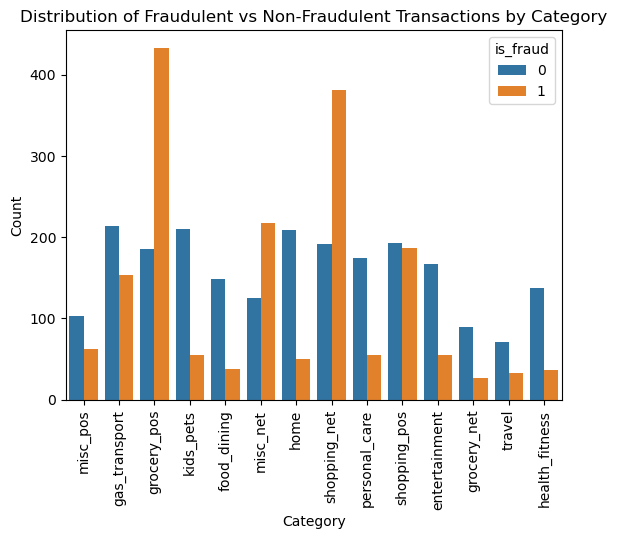

In [186]:
sns.countplot(x='category', hue='is_fraud', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


This countplot compares fraud and non-fraud transactions across different categories and highlights which categories have the highest fraud cases. From the graph, it can be observed that most fraud cases occur in the grocery_pos and shopping_net categories. This indicates that online shopping and grocery-related transactions are more frequently targeted for fraud, suggesting that these categories may require stricter monitoring and enhanced security measures.

### **4. What does the city-wise fraud analysis show?**

In [187]:
df.city.nunique()

176

In [188]:
df.city.value_counts()

Phoenix          67
Glendale         50
Sacramento       49
Fort Washakie    48
Centerview       46
                 ..
Kirtland Afb      8
Odessa            7
Vacaville         7
Vancouver         6
Woods Cross       5
Name: city, Length: 176, dtype: int64

In [189]:
df.groupby('city')['is_fraud'].value_counts()

city                       is_fraud
Albuquerque                1           24
                           0            8
Altonah                    0           15
                           1           14
Alva                       0            9
                                       ..
Williamsburg               1           13
                           0            7
Woods Cross                0            5
Yellowstone National Park  1           12
                           0            4
Name: is_fraud, Length: 334, dtype: int64

In [190]:
df['city'][df['is_fraud'] == 1].value_counts().head(20)

Albuquerque      24
Aurora           23
Fort Washakie    21
Mesa             20
Glendale         20
Seattle          19
Hubbell          19
San Jose         18
San Diego        18
Phoenix          17
Sacramento       16
North Loup       16
Bay City         15
Mound City       15
Freedom          15
Wales            15
Lowell           15
Carlotta         15
Coulee Dam       15
Sutherland       15
Name: city, dtype: int64

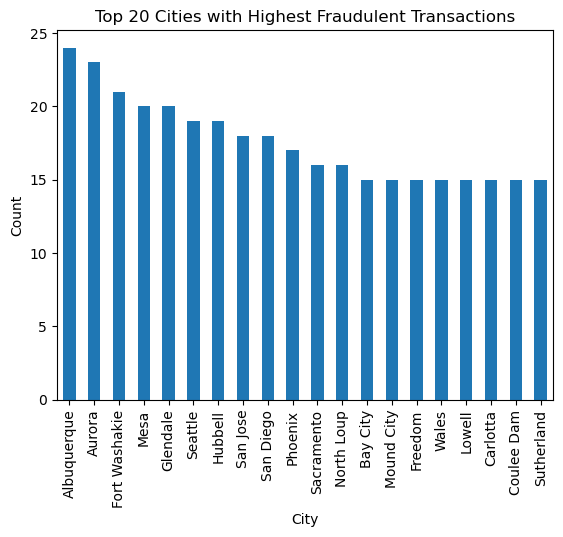

In [191]:
df['city'][df['is_fraud'] == 1].value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Cities with Highest Fraudulent Transactions')
plt.xlabel('City')
plt.ylabel('Count')
plt.show()

This bar graph shows the top 20 cities with the highest number of fraud transactions. Only fraud cases (is fraud 1) are considered in this analysis. The x-axis represents the cities, while the y-axis shows the fraud count. From the graph, it can be observed that Albuquerque, Aurora, and Fort Washakle have the highest number of fraud transactions. This indicates that fraud incidents are more concentrated in certain cities rather than being evenly distributed across all locations.

### **5. What does the city population fraud analysis show?**

In [192]:
df.groupby('city')['city_pop'].value_counts().head(20)

city                city_pop
Albuquerque         641349      32
Altonah             302         29
Alva                110         18
American Fork       42384       20
Angwin              3661        10
Arnold              35439       25
Arvada              122111      13
Ashford             759         22
Athena              1302        25
Aurora              389246      30
Azusa               59705       15
Ballwin             92608       11
Bay City            1530        18
Blairsden-Graeagle  1725        16
Blairstown          467         21
Brainard            614          9
Brashear            805         16
Broomfield          92337       10
Browning            602         24
Buellton            5505         8
Name: city_pop, dtype: int64

In [193]:
df[df['is_fraud'] == 1].groupby(['city', 'city_pop']).size().head(20)

city                city_pop
Albuquerque         641349      24
Altonah             302         14
Alva                110          9
American Fork       42384        8
Angwin              3661        10
Arnold              35439        8
Arvada              122111       9
Ashford             759         12
Athena              1302         8
Aurora              389246      23
Azusa               59705       11
Bay City            1530        15
Blairsden-Graeagle  1725         9
Blairstown          467          5
Brainard            614          5
Brashear            805         13
Broomfield          92337        7
Browning            602          5
Buellton            5505         8
Burbank             3684         7
dtype: int64

<Axes: xlabel='city,city_pop'>

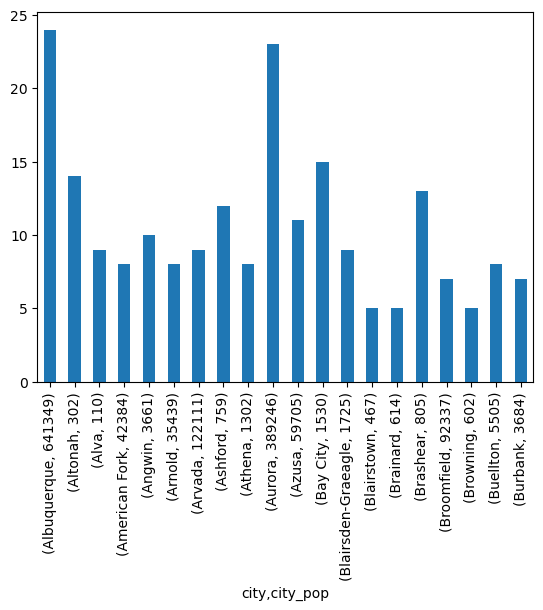

In [194]:
df[df['is_fraud'] == 1].groupby(['city', 'city_pop']).size().head(20).plot(kind='bar')

According to the given analysis the 'Albuquerque' which has 641349 population has the highest fraud rate having 24 cases , while on the other hand the 'Aurora'  which has 389246 population has the 2nd highest fraud rate having 23 cases. This indicates that the cities with higher population has the mostly fraud cases . 

### **6. What does the bar graph of fraud transactions by state show?**

In [195]:
df.state.nunique()

13

In [196]:
df.state.value_counts()

CA    942
MO    641
NE    431
OR    372
WA    284
WY    283
NM    265
CO    240
AZ    177
UT    149
ID     98
AK     76
HI     42
Name: state, dtype: int64

In [197]:
df['state'][df['is_fraud'] == 1].value_counts()

CA    402
MO    262
NE    216
OR    197
WA    126
NM    121
WY    119
CO    115
AZ     64
UT     61
AK     50
ID     33
HI     16
Name: state, dtype: int64

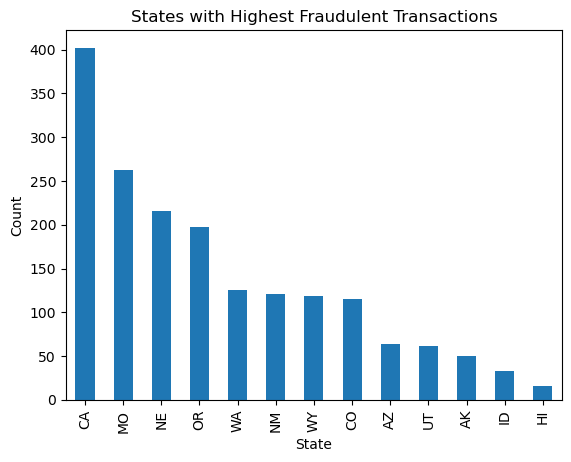

In [198]:
df['state'][df['is_fraud'] == 1].value_counts().plot(kind='bar')
plt.title('States with Highest Fraudulent Transactions')
plt.xlabel('State')
plt.ylabel('Count')
plt.show()


This bar graph shows fraud transactions in different states where only fraud cases (is_fraud = 1) are included. California (CA) has the highest fraud count with 402 cases, followed by Missouri (MO) with 262 cases. Nebraska (NE) has 216, and Oregon (OR) has 197, showing a higher level of fraud in these states. Other states have lower fraud counts like Washington (WA: 126), New Mexico (NM: 121), Wyoming (WY: 119), and Colorado (CO: 115). States such as Arizona (AZ: 64), Utah (UT: 61), Alaska (AK: 50), and Idaho (ID: 33) show even fewer cases. Hawaii (HI) has the lowest fraud count with 16 cases.  
Overall, fraud is mostly concentrated in a few states like CA and MO, so these areas may need stronger fraud checks and security.

In [199]:
df['trans_date_trans_time'].head(10)

0   2019-08-05 00:22:03
1   2020-08-27 11:53:54
2   2019-07-26 01:05:31
3   2020-12-13 12:54:28
4   2020-02-04 16:08:47
5   2019-01-28 01:51:12
6   2020-12-08 02:44:41
7   2019-03-07 01:45:07
8   2019-03-04 22:50:43
9   2019-10-18 19:44:09
Name: trans_date_trans_time, dtype: datetime64[ns]

### **7. What does the hourly fraud pattern show?**

In [200]:
df.trans_date_trans_time.dt.hour.head(10)

0     0
1    11
2     1
3    12
4    16
5     1
6     2
7     1
8    22
9    19
Name: trans_date_trans_time, dtype: int64

In [201]:
df[df['is_fraud'] == 1].groupby(df['trans_date_trans_time'].dt.hour).size()

trans_date_trans_time
0     168
1     168
2     140
3     143
4       7
5      10
6       7
7       9
8      12
9      11
10     10
11      6
12     17
13     14
14     15
15     22
16     23
17     20
18     18
19     11
20     23
21     17
22    452
23    459
dtype: int64

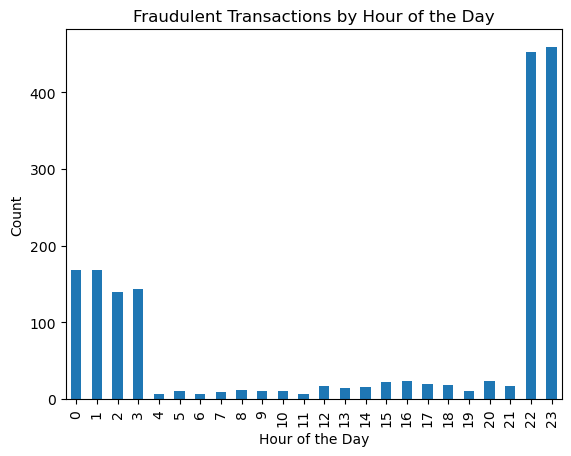

In [202]:
df[df['is_fraud'] == 1].groupby(df['trans_date_trans_time'].dt.hour).size().plot(kind='bar')
plt.title('Fraudulent Transactions by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.show()

This bar graph shows fraud transactions across different hours of the day where only fraud cases (is_fraud = 1) are included. The x-axis represents hours (0-23), and the y-axis shows fraud count. From the pattern, the highest fraud activity is seen at 23:00 (459 cases) and 22:00 (452 cases), showing a clear peak at late night hours. Early morning hours like 00:00-03:00 also show consistently high fraud counts (around 140-168 cases), which is still relatively active compared to daytime.  
Overall, fraud is mostly happening during late night hours (22-23), which suggests that fraud activity increases when monitoring or user activity is lower, making these hours more sensitive for security control.

### **8. What does the monthly fraud pattem show?**

In [203]:
df['trans_date_trans_time'].dt.month.head(10)

0     8
1     8
2     7
3    12
4     2
5     1
6    12
7     3
8     3
9    10
Name: trans_date_trans_time, dtype: int64

In [204]:
df[df['is_fraud'] == 1].groupby(df['trans_date_trans_time'].dt.month).size()

trans_date_trans_time
1     141
2     169
3     220
4     120
5     167
6      92
7     125
8     156
9     197
10    150
11     83
12    162
dtype: int64

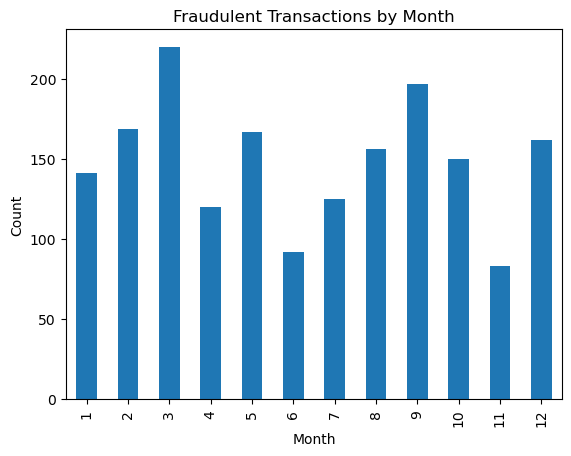

In [205]:
df[df['is_fraud'] == 1].groupby(df['trans_date_trans_time'].dt.month).size().plot(kind='bar')
plt.title('Fraudulent Transactions by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

This bar graph shows fraud transactions across different months where only fraud cases (is_fraud 1) are included. The x-axis represents months (1-12), and the y-axis shows fraud count. The highest fraud activity is seen in March (220 cases), followed by September (197 cases) and February (169 cases). Moderate fraud is seen in months like May (167), December (162), and August (156). The lowest fraud cases are observed in June and November, showing a clear drop in these months.  
Overall, fraud is not evenly spread throughout the year. It peaks in some months like March and September, while dropping in mid-year and end-of-year months like June and November.

### **9. What does the yearly fraud pattern show?**

In [206]:
df['trans_date_trans_time'].dt.year.head(10)

0    2019
1    2020
2    2019
3    2020
4    2020
5    2019
6    2020
7    2019
8    2019
9    2019
Name: trans_date_trans_time, dtype: int64

In [207]:
df['trans_date_trans_time'].dt.year.unique()

array([2019, 2020], dtype=int64)

In [208]:
df[df['is_fraud'] == 1]['trans_date_trans_time'].dt.year.value_counts()

2019    978
2020    804
Name: trans_date_trans_time, dtype: int64

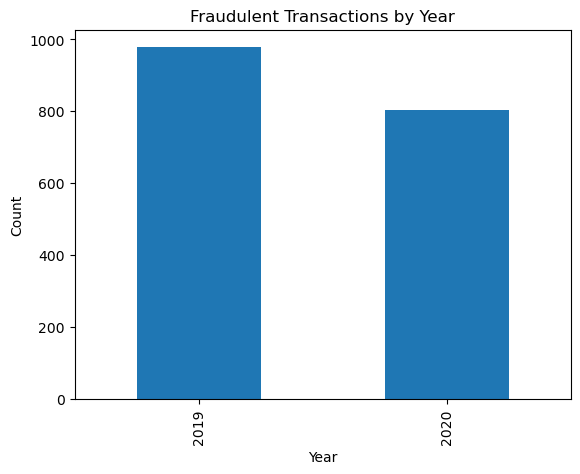

In [209]:
df[df['is_fraud'] == 1].groupby(df['trans_date_trans_time'].dt.year).size().plot(kind='bar')
plt.title('Fraudulent Transactions by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

This bar graph shows fraud transactions in the years 2019 and 2020 where only fraud cases (is fraud 1) are included. The x-axis represents the years and the y-axis shows fraud count. In 2019, fraud cases are higher with 978 transactions, while in 2020 fraud cases decrease to 804 transactions.  
Overall, there is a clear drop in fraud from 2019 to 2020, which suggests a slight improvement or change in fraud activity pattern over time.

In [210]:
df.columns

Index(['trans_date_trans_time', 'category', 'amt', 'city', 'state', 'lat',
       'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

### **10. What does the correlation between Amount and Fraud show?**

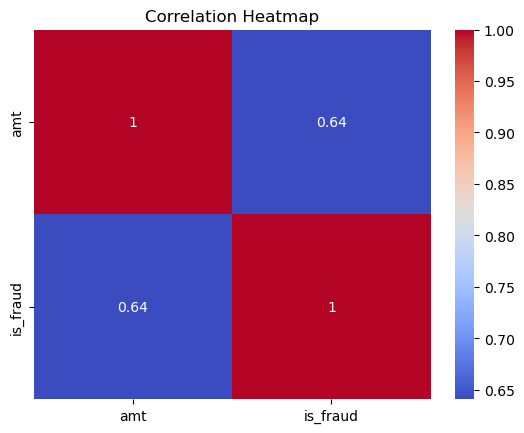

In [211]:
sns.heatmap(df[['amt', 'is_fraud']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


This heatmap shows the correlation between transaction amount (amt) and fraud (is fraud). The diagonal value is 1, which represents a perfect relationship of each variable with itself. The correlation between amount and fraud is 0.64, which shows a moderate positive relationship. This means that as transaction amount increases, the chances of fraud also tend to increase to some extent. However, this is not a strong relationship. So, amount alone is not enough to detect fraud. Other features are also needed for better fraud detection.

# **Conlusion:**  
This EDA shows that fraud transactions are not evenly distributed across the dataset. Fraud is higher in certain states and cities, especially CA and MO. It also shows clear time-based patterns, where most fraud cases occur during late-night hours, especially at 22:00 and 23:00. Some months like March and September show higher fraud activity, while June and November show relatively lower cases.  
The correlation analysis shows that transaction amount has a moderate relationship with fraud, but it is not strong enough to detect fraud alone. This means fraud detection cannot depend on a single feature.  
Overall, fraud patterns depend on multiple factors such as time, location, and transaction details. These insights can help in building a better fraud detection system by using multiple features instead of relying on only one variable.

# **Developing Model:**

In [212]:
df.columns

Index(['trans_date_trans_time', 'category', 'amt', 'city', 'state', 'lat',
       'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [213]:
df.drop(columns=['city', 'city_pop'], inplace=True)

### Making Age column:

In [214]:
df['age']= 2026 - pd.to_datetime(df['dob']).dt.year
df['age'].head()

0    42
1    66
2    69
3    86
4    51
Name: age, dtype: int64

### Making Distance column:

In [215]:
df['distance'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long']) ** 2)
df['distance'].head()

0    0.516192
1    0.503908
2    0.929072
3    0.723208
4    0.704131
Name: distance, dtype: float64

> Distance feature represents the approximate distance between customer's location and merchant's location.
> Fraud transactions may occur far away from the customer's usual location, making distance animportant feature for fraud detection.

In [216]:
df.columns

Index(['trans_date_trans_time', 'category', 'amt', 'state', 'lat', 'long',
       'dob', 'merch_lat', 'merch_long', 'is_fraud', 'age', 'distance'],
      dtype='object')

### Making Hour and Day column:

In [217]:
df['hours'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour
df['day'] = pd.to_datetime(df['trans_date_trans_time']).dt.dayofweek

In [218]:
df['hours'].sample(5)

3573    22
1820    22
3848    17
1343     3
1285     3
Name: hours, dtype: int64

In [219]:
df['day'].sample(5)

507     0
1336    0
1749    1
1729    0
3795    1
Name: day, dtype: int64

In [220]:
df.columns

Index(['trans_date_trans_time', 'category', 'amt', 'state', 'lat', 'long',
       'dob', 'merch_lat', 'merch_long', 'is_fraud', 'age', 'distance',
       'hours', 'day'],
      dtype='object')

### Dropping Columns:

In [221]:
df.drop(columns=['lat', 'long', 'dob', 'merch_lat', 'merch_long' , 'trans_date_trans_time'], inplace=True)

In [222]:
df.columns

Index(['category', 'amt', 'state', 'is_fraud', 'age', 'distance', 'hours',
       'day'],
      dtype='object')

### Training the model:

In [223]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(df.drop('is_fraud' , axis= 1) , df['is_fraud'] , test_size= 0.2 , random_state = 42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((3200, 7), (800, 7), (3200,), (800,))

In [224]:
X_train.sample(5)

,category,amt,state,age,distance,hours,day
2379,shopping_pos,787.51,OR,61,0.689702,23,1
3593,personal_care,20.56,NE,46,0.706144,23,1
2898,grocery_pos,302.20,MO,28,0.099674,2,2
3988,grocery_pos,339.80,UT,65,0.736567,4,5
2565,gas_transport,83.95,CA,31,0.993049,3,1


### Applying One hot encoding:

In [225]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
trf1 = ColumnTransformer([
    ('encoder', OneHotEncoder(handle_unknown='ignore'), ['category', 'state'])
], remainder='passthrough')

We are doing One hot encoding on Category and state column because in Machine learning the values in attributes must have to be in numeric instead of string because ML donot understand 'text' . By applying One hot encoding we can encode the category and stats attributes in numeric form so that our model can read them as well.

### Applying Machine learning Algorithm:

In [226]:
from sklearn.ensemble import RandomForestClassifier
trf2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    random_state=42
)

We are using Random Forest Classifier model because this algorithm is best to find classification outputs (Boolean output) such as 0 & 1 , Yes or No , True or False etc . 

### Creating Pipeline:

In [227]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('trf1', trf1),
    ('trf2', trf2)
])

In [228]:
pipe.fit(X_train, y_train)

,steps,"[('trf1', ...), ('trf2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [229]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,

In [230]:
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {Accuracy * 100 :.2f}%')

Accuracy: 87.50%


In [231]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X_train, y_train, cv=5)
print(f'Cross-validation Accuracy: {scores.mean() * 100:.2f}%')

Cross-validation Accuracy: 88.09%


# **Testing the model:**

In [232]:
sample = pd.DataFrame([{
    'category': 'mis',
    'amt': 321,
    'state': 'AZ',
    'age': 56,
    'distance': 0,
    'hours': 0,
    'day': 8
}])

prediction = pipe.predict(sample)[0]

if prediction == 1:
    print("The transaction is predicted to be fraudulent.")
else:
    print("The transaction is predicted to be non-fraudulent.")

The transaction is predicted to be fraudulent.


It showed that transaction amount (amt) had the strongest impact on fraud prediction. This suggests that fraudulent transactions often involve unusual transaction amounts. Additional engineered features such as transaction hour and distance were included to improve model learning beyond amount alone.

# **Conclusion:**

This project successfully developed a machine learning model
for fraud transaction detection.

Key tasks performed:
- Data cleaning and preprocessing
- Feature engineering
- Handling imbalanced data
- Exploratory Data Analysis (EDA)
- Model training using Random Forest
- Performance evaluation

The model achieved good performance and was able to identify
fraudulent transactions effectively.

In [233]:
pip install pyarrow


Note: you may need to restart the kernel to use updated packages.
